# ASAP-SAS : Scoring Automatique de Réponses Courtes

**Objectif** : Développer un modèle de classification multi-classes pour prédire automatiquement le score d'une réponse courte d'étudiant.

**Métriques d'évaluation** : Quadratic Weighted Kappa (QWK) + Accuracy

**État de l'art à battre** : BERT (Mean QWK = 0.71)

---
## 1. Importation des Bibliothèques

In [45]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Prétraitement et métriques
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

# Sentence-BERT pour embeddings
from sentence_transformers import SentenceTransformer

# PyTorch pour le modèle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuration
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device : {device}")

 Device : cuda


---
## 2. Chargement des Données

*Charger le fichier depuis Drive (À CHAQUE SESSION)*

In [46]:
# import pandas as pd

# train_path = "/content/train.tsv"

# df = pd.read_csv(train_path, sep='\t', encoding='latin-1')


In [47]:
# print(f" Dataset: {df.shape[0]} réponses, {df.shape[1]} colonnes")
# print(f"\n Colonnes: {list(df.columns)}")
# df.head(10)

In [48]:
# import pandas as pd

# # Charger les deux datasets
# df1 = pd.read_csv("public_leaderboard_rel_2.tsv", sep="\t")
# df2 = pd.read_csv("public_leaderboard.tsv", sep="\t")

# # Fusionner (empiler les lignes)
# df3 = pd.concat([df1, df2], ignore_index=True)

# # Supprimer les doublons sur la colonne id
# df3 = df3.drop_duplicates(subset="Id")

# print("Taille finale :", df3.shape)
# print(df3.head())

In [49]:
# df4 = pd.read_csv("/content/public_leaderboard_solution.csv")
# print(df4.head())

In [50]:
# df4.value_counts('essay_weight')

In [51]:
# # Fusion selon l'id (Id dans df et id dans df3)
# df5= pd.merge(
#     df3,
#     df4,
#     left_on="Id",
#     right_on="id",
#     how="inner"
# )

# # Garder seulement les colonnes voulues
# df5 = df5[["id", "essay_set", "essay_score", "EssayText"]]

# # Renommer essay_score en Score1
# df5 = df5.rename(columns={"essay_score": "Score1"})
# df5 = df5.rename(columns={"essay_set": "EssaySet"})
# # Afficher le résultat
# print(df5.head())


In [52]:
# import pandas as pd

# # Charger les fichiers TSV
# df1_1 = pd.read_csv("train.tsv", sep="\t")
# df2_1 = pd.read_csv("train_rel_2.tsv", sep="\t")

# # Concaténer les lignes
# df6= pd.concat([df1_1, df2_1], ignore_index=True)

# # Vérifier
# print(df6.shape)
# print(df6.head())

# # # Optionnel : sauvegarder
# # df6.to_csv("train_fusion.tsv", sep="\t", index=False)

# Data final

In [53]:
# Concaténer les lignes
df = pd.read_csv("dataset_final.csv")

# Vérifier
print(df.shape)
print(df.head())

(39474, 4)
       id  EssaySet  Score1                                          EssayText
0  1673.0         1       1  The procedures I think they should have includ...
1  1674.0         1       1  In order to replicate this experiment, you wou...
2  1675.0         1       3  In order to replicate their experiment, you wo...
3  1676.0         1       0  Pleace a simple of one material into one conta...
4  1677.0         1       0  Determin the mass of four different samples ma...


In [54]:
df = df[["id", "EssaySet", "Score1", "EssayText"]]

In [55]:
print(df.head())

       id  EssaySet  Score1                                          EssayText
0  1673.0         1       1  The procedures I think they should have includ...
1  1674.0         1       1  In order to replicate this experiment, you wou...
2  1675.0         1       3  In order to replicate their experiment, you wo...
3  1676.0         1       0  Pleace a simple of one material into one conta...
4  1677.0         1       0  Determin the mass of four different samples ma...


In [56]:
df.to_csv("dataset_final.csv", index=False)

In [57]:
# Filtrer le dataset pour EssaySet == 3
essays_set3 = df[df['EssaySet'] == 3]

# Afficher Score1 + EssayText pour les 20 premiers exemples
for i, row in enumerate(essays_set3[['Score1', 'EssayText']][:20].itertuples(index=False)):
    score, text = row
    print(f"{i+1}: Score1 = {score} | {text}\n")

1: Score1 = 1 | As described in the article, pandas eat an abundance of bamboo and therefore are specialist to China, while the koala ''eats eucalyptus leaves almost exclusively.'' Both these animals are specialists to one habitat while the python, a generalist is able to live in a wider range of habitats virtually anywhere.

2: Score1 = 1 | Pandas and koalas are similar because they both need a certain food that they eat such as bamboo and eucalyptus leaves but a python will not eat anything but it needs in certain climate to be able to live there.

3: Score1 = 1 | Pandas in China and Koalas in Australia eat only bamboo and eucalyptus leaves almost exclusively according to the author. For this reason, they are both specialists. However a the article states a python is a generalist and able to inhabit a number of different locations around the world, unlike the Panda and Koala who are limited to their native countries.

4: Score1 = 1 | Pandas are similar to koalas because they are both

In [58]:
# Informations générales
print(" Informations du dataset:")
df.info()
print("\n Valeurs manquantes:")
df.isnull().sum()

 Informations du dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39474 entries, 0 to 39473
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         5224 non-null   float64
 1   EssaySet   39474 non-null  int64  
 2   Score1     39474 non-null  int64  
 3   EssayText  39474 non-null  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 1.2+ MB

 Valeurs manquantes:


,0
id,34250
EssaySet,0
Score1,0
EssayText,0


---
## 3. Exploration des Données (EDA)

Nous allons analyser la distribution des scores, les longueurs de réponses et les particularités par question.

In [59]:
# Calcul de la longueur des réponses
df['answer_length'] = df['EssayText'].apply(lambda x: len(str(x).split()))
print("- Statistiques sur la longueur des réponses (en mots):")
print(df['answer_length'].describe())

- Statistiques sur la longueur des réponses (en mots):
count    39474.000000
mean        42.361732
std         27.348116
min          1.000000
25%         23.000000
50%         39.000000
75%         56.000000
max        325.000000
Name: answer_length, dtype: float64


### 3.1 Choix du Score de Référence

Dans ce projet, nous utilisons **`Score1` comme score final**, car il correspond à la note officielle attribuée à l’essai et c’est celle que le modèle doit prédire.
**`Score2`** sert uniquement à vérifier l’accord entre les correcteurs et n’est pas utilisé pour l’entraînement.

In [60]:
# Corrélation entre Score1 et Score2
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

# qwk_inter = quadratic_weighted_kappa(df['Score1'], df['Score2'])
# print(f"- QWK entre Score1 et Score2: {qwk_inter:.3f}")

 Le faite que QWK = 0.913 (proche de 1) indique un accord élevé entre les deux évaluateurs humains, ce qui valide la cohérence du dataset.


### 3.2 Distribution Globale des Scores

**Observation** : Déséquilibre des classes détecté (Score 3 est minoritaire)

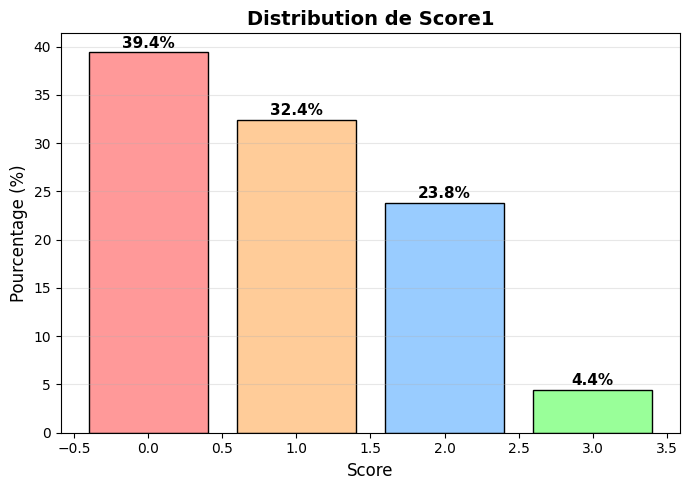


-> Déséquilibre des classes:
   Score 0: 15563 exemples ( 39.4%)
   Score 1: 12781 exemples ( 32.4%)
   Score 2:  9396 exemples ( 23.8%)
   Score 3:  1734 exemples (  4.4%)


In [61]:
# Visualisation de la distribution
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Distribution avec pourcentages
score_pct = (df['Score1'].value_counts(normalize=True)
             .sort_index() * 100).round(1)

colors = ['#ff9999', '#ffcc99', '#99ccff', '#99ff99']
bars = ax.bar(
    score_pct.index,
    score_pct.values,
    color=colors[:len(score_pct)],
    edgecolor='black'
)

ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_title('Distribution de Score1', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Affichage des pourcentages
for bar, pct in zip(bars, score_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print(f"\n-> Déséquilibre des classes:")
for score in sorted(df['Score1'].unique()):
    count = (df['Score1'] == score).sum()
    pct = count / len(df) * 100
    print(f"   Score {score}: {count:5d} exemples ({pct:5.1f}%)")


**Point important** : Nous observons que les scores ne sont pas équilibrés. Les scores 0, 1, et 2 sont beaucoup plus fréquents que le score 3. Ce déséquilibre sera pris en compte lors de l'entraînement grâce au **class weighting**.

### 3.3 Distribution par Question

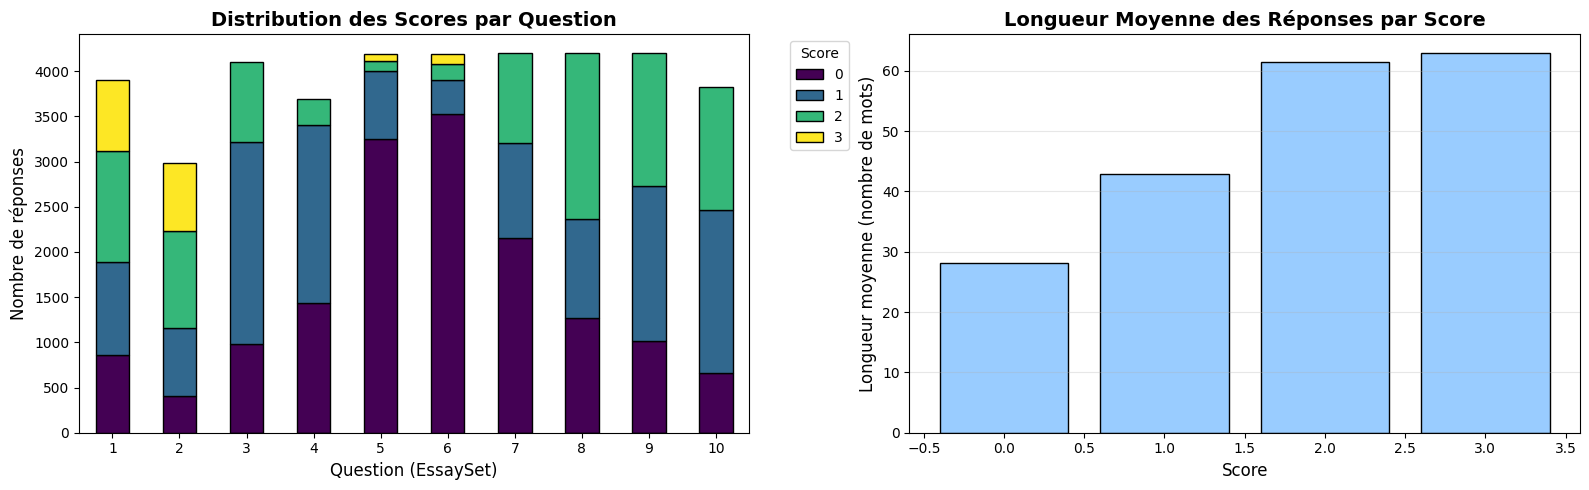


- Classes disponibles par question:
   Question  1: 4 classes
   Question  2: 4 classes
   Question  3: 3 classes
   Question  4: 3 classes
   Question  5: 4 classes
   Question  6: 4 classes
   Question  7: 3 classes
   Question  8: 3 classes
   Question  9: 3 classes
   Question 10: 3 classes


In [62]:
# Distribution des scores par question
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar chart (INCHANGÉ)
score_by_question = df.groupby(['EssaySet', 'Score1']).size().unstack(fill_value=0)
score_by_question.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='viridis',
    edgecolor='black'
)

axes[0].set_xlabel('Question (EssaySet)', fontsize=12)
axes[0].set_ylabel('Nombre de réponses', fontsize=12)
axes[0].set_title('Distribution des Scores par Question', fontsize=14, fontweight='bold')
axes[0].legend(title='Score', bbox_to_anchor=(1.05, 1))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Longueur moyenne par score (REMPLACE le boxplot)
mean_length = df.groupby('Score1')['answer_length'].mean()

axes[1].bar(
    mean_length.index,
    mean_length.values,
    color='#99ccff',
    edgecolor='black'
)

axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_ylabel('Longueur moyenne (nombre de mots)', fontsize=12)
axes[1].set_title('Longueur Moyenne des Réponses par Score', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse du nombre de classes par question
print("\n- Classes disponibles par question:")
for q in range(1, 11):
    scores = sorted(df[df['EssaySet'] == q]['Score1'].unique())
    n_classes = len(scores)
    print(f"   Question {q:2d}: {n_classes} classes")


 **Interprétation**

La longueur moyenne des réponses **augmente avec le score**, ce qui indique que les réponses plus longues tendent à obtenir de meilleures notes.  
Cependant, la longueur seule n’est pas suffisante et doit être combinée avec d’autres caractéristiques textuelles.

Le nombre de classes varie selon les questions : certaines ont **4 classes de score**, tandis que d’autres n’en ont que **3**.  
Cette variation montre que la **question (EssaySet)** doit être prise en compte lors de la modélisation.







---
## 4. Prétraitement des Données

**Philosophie** : Nettoyage minimal pour préserver les erreurs des étudiants (indicateurs de qualité)

In [63]:
def clean_text(text):
    """
    Nettoyage léger du texte:
    - Normalisation des espaces
    - Suppression des caractères spéciaux inutiles
    - Préservation de la ponctuation et de la structure
    """
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)  # Espaces multiples → 1 espace
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"\-]', '', text)  # Garder ponctuation de base
    return text

# Application du prétraitement
df['EssayText_clean'] = df['EssayText'].apply(clean_text)

print(" Prétraitement appliqué")
print("\nExemple de transformation:")
print("AVANT:", df['EssayText'].iloc[0][:100])
print("APRÈS:", df['EssayText_clean'].iloc[0][:100])

 Prétraitement appliqué

Exemple de transformation:
AVANT: The procedures I think they should have included inorder for me to replicate the experiment would be
APRÈS: The procedures I think they should have included inorder for me to replicate the experiment would be


### 4.1 Préparation de la Variable Cible

In [64]:
# Les scores vont de 0 à 3, parfait pour classification multi-classes
df['target'] = df['Score1']
num_classes = df['target'].nunique()
print(f"Nombre de classes: {num_classes}")
print(f"   Classes: {sorted(df['target'].unique())}")

Nombre de classes: 4
   Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


---
## 5. Split des Données (70% / 15% / 15%)

**Stratification** : Préserver la distribution des scores dans chaque ensemble

In [65]:
# Split stratifié
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['target'])

print("- Répartition des données:")
print(f"   Train: {len(train_df):5d} ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Val:   {len(val_df):5d} ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test:  {len(test_df):5d} ({len(test_df)/len(df)*100:.1f}%)")

print("\n Distribution préservée (stratification):")
print("\nTrain:")
print(train_df['target'].value_counts(normalize=True).sort_index().round(3))
print("\nTest:")
print(test_df['target'].value_counts(normalize=True).sort_index().round(3))

- Répartition des données:
   Train: 27631 (70.0%)
   Val:    5921 (15.0%)
   Test:   5922 (15.0%)

 Distribution préservée (stratification):

Train:
target
0    0.394
1    0.324
2    0.238
3    0.044
Name: proportion, dtype: float64

Test:
target
0    0.394
1    0.324
2    0.238
3    0.044
Name: proportion, dtype: float64


---
## 6. Encodage avec Sentence-BERT

**Modèle** : `all-mpnet-base-v2` (768 dimensions)
- Meilleur modèle Sentence-BERT pour tâches générales
- Pré-entraîné sur 1 milliard de paires de phrases

In [66]:
# Chargement du modèle
print(" Chargement de Sentence-BERT...")
sbert_model = SentenceTransformer('all-mpnet-base-v2')
print("✅ Modèle chargé: all-mpnet-base-v2")

# Génération des embeddings
print("\n Génération des embeddings...")
X_train = sbert_model.encode(train_df['EssayText_clean'].tolist(), show_progress_bar=True, batch_size=32)
X_val = sbert_model.encode(val_df['EssayText_clean'].tolist(), show_progress_bar=True, batch_size=32)
X_test = sbert_model.encode(test_df['EssayText_clean'].tolist(), show_progress_bar=True, batch_size=32)

y_train = train_df['target'].values
y_val = val_df['target'].values
y_test = test_df['target'].values

print(f"\n Embeddings générés:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")

 Chargement de Sentence-BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé: all-mpnet-base-v2

 Génération des embeddings...


Batches:   0%|          | 0/864 [00:00<?, ?it/s]

Batches:   0%|          | 0/186 [00:00<?, ?it/s]

Batches:   0%|          | 0/186 [00:00<?, ?it/s]


 Embeddings générés:
   X_train: (27631, 768)
   X_val:   (5921, 768)
   X_test:  (5922, 768)


### fine-tuning SBERT pour prédire le score

In [67]:
# from sentence_transformers import SentenceTransformer, InputExample, losses
# from torch.utils.data import DataLoader

# model = SentenceTransformer('all-mpnet-base-v2')

# train_examples = [
#     InputExample(texts=[text], label=float(score))
#     for text, score in zip(train_df['EssayText_clean'], train_df['target'])
# ]

# train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# train_loss = losses.MSELoss(model)

# model.fit(
#     train_objectives=[(train_dataloader, train_loss)],
#     epochs=3,
#     warmup_steps=100,
#     output_path="sbert_regression_finetuned"
# )


In [68]:
# sbert_finetuned = SentenceTransformer("sbert_regression_finetuned")

# X_train = sbert_finetuned.encode(train_df['EssayText_clean'].tolist(), batch_size=32)
# X_val   = sbert_finetuned.encode(val_df['EssayText_clean'].tolist(), batch_size=32)
# X_test  = sbert_finetuned.encode(test_df['EssayText_clean'].tolist(), batch_size=32)

---
## 7. Calcul des Class Weights

**Solution au déséquilibre** : Pénaliser davantage les erreurs sur classes minoritaires

In [69]:
# Calcul des poids
classes = np.unique(y_train)
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print("- Class weights calculés:")
for score, weight in zip(classes, class_weights_array):
    print(f"   Score {score}: {weight:.3f}")
print("\n→ Les classes minoritaires auront plus de poids dans la loss")

- Class weights calculés:
   Score 0: 0.634
   Score 1: 0.772
   Score 2: 1.050
   Score 3: 5.690

→ Les classes minoritaires auront plus de poids dans la loss


---
## 8. Préparation des DataLoaders PyTorch

In [70]:
class TextDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Création des datasets
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f" DataLoaders créés (batch_size={batch_size})")

 DataLoaders créés (batch_size=32)


---
## 9. Modèle de Classification (PyTorch MLP)

**Architecture** : Réseau de neurones profond avec régularisation

In [71]:
class ClassificationModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super(ClassificationModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout * 0.7),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Initialisation
model = ClassificationModel(input_dim=768, num_classes=num_classes, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(" Modèle créé")
print(f"\nNombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")

 Modèle créé

Nombre de paramètres: 560,260


In [72]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.4, use_residual=True):
        super(ImprovedMLP, self).__init__()
        self.use_residual = use_residual

        # Couche 1
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(dropout_rate)

        # Couche 2
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Couche 3
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(dropout_rate * 0.8)

        # Couche 4
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.dropout4 = nn.Dropout(dropout_rate * 0.6)

        # Couche de sortie
        self.fc_out = nn.Linear(64, num_classes)

        # Activation
        self.gelu = nn.GELU()

        # Projection pour residual si nécessaire
        if use_residual:
            self.residual_proj = nn.Linear(512, 128)

    def forward(self, x):
        # Layer 1
        x1 = self.gelu(self.bn1(self.fc1(x)))
        x1 = self.dropout1(x1)

        # Layer 2
        x2 = self.gelu(self.bn2(self.fc2(x1)))
        x2 = self.dropout2(x2)

        # Layer 3
        x3 = self.gelu(self.bn3(self.fc3(x2)))
        x3 = self.dropout3(x3)

        # Residual connection
        if self.use_residual:
            x3 = x3 + self.residual_proj(x1)

        # Layer 4
        x4 = self.gelu(self.bn4(self.fc4(x3)))
        x4 = self.dropout4(x4)

        # Output
        out = self.fc_out(x4)
        return out

print(" Architecture ImprovedMLP définie")

 Architecture ImprovedMLP définie


In [73]:
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, epsilon=0.1, weight=None):
        super().__init__()
        self.epsilon = epsilon
        self.weight = weight

    def forward(self, pred, target):
        n_classes = pred.size(-1)
        log_pred = torch.log_softmax(pred, dim=-1)

        # Label smoothing
        with torch.no_grad():
            true_dist = torch.zeros_like(log_pred)
            true_dist.fill_(self.epsilon / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.epsilon)

        loss = torch.sum(-true_dist * log_pred, dim=-1)

        # Application des poids de classe
        if self.weight is not None:
            weights = self.weight[target]
            loss = loss * weights

        return loss.mean()

print(" Loss avec Label Smoothing définie")

 Loss avec Label Smoothing définie


---
## 10. Entraînement


In [74]:
# Hyperparamètres par question
hyperparams = {
    1: {'lr': 0.001, 'dropout': 0.4, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    2: {'lr': 0.001, 'dropout': 0.4, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    3: {'lr': 0.0005, 'dropout': 0.5, 'epochs': 150, 'batch_size': 16, 'label_smoothing': 0.15},  # Spécial Q3
    4: {'lr': 0.001, 'dropout': 0.3, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    5: {'lr': 0.001, 'dropout': 0.3, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    6: {'lr': 0.001, 'dropout': 0.3, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    7: {'lr': 0.001, 'dropout': 0.4, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    8: {'lr': 0.001, 'dropout': 0.4, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    9: {'lr': 0.001, 'dropout': 0.4, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
    10: {'lr': 0.001, 'dropout': 0.4, 'epochs': 100, 'batch_size': 32, 'label_smoothing': 0.1},
}

In [75]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device, clip_grad=1.0):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    qwk = quadratic_weighted_kappa(all_labels, all_preds)

    return avg_loss, acc, qwk

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings = embeddings.to(device)
            outputs = model(embeddings)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    qwk = quadratic_weighted_kappa(all_labels, all_preds)

    return all_preds, all_labels, acc, qwk

print("Fonctions d'entraînement définies")

Fonctions d'entraînement définies


In [76]:
import torch.nn.functional as F
from torch.optim.lr_scheduler import OneCycleLR

# ==========================================
# 1. PRÉPARATION DES DONNÉES PAR QUESTION
# ==========================================
print(" Préparation des données par question...")
question_data = {}

for q in range(1, 11):
    train_mask = train_df['EssaySet'] == q
    test_mask = test_df['EssaySet'] == q

    X_q_train = X_train[train_mask.values]
    y_q_train = y_train[train_mask.values]
    X_q_test = X_test[test_mask.values]
    y_q_test = y_test[test_mask.values]

    classes = np.unique(y_q_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_q_train)

    question_data[q] = {
        'X_train': X_q_train,
        'y_train': y_q_train,
        'X_test': X_q_test,
        'y_test': y_q_test,
        'n_classes': len(np.unique(df[df['EssaySet'] == q]['target'])),
        'class_weights': weights
    }

# ==========================================
# 2. ARCHITECTURE ET FONCTIONS (Inchangées)
# ==========================================
# [Gardez vos classes ImprovedMLP et LabelSmoothingCrossEntropy ici]

# ==========================================
# 3. BOUCLE D'ENTRAÎNEMENT AMÉLIORÉE
# ==========================================

# INITIALISATION DES DICTIONNAIRES DE STOCKAGE
models = {}
results = {}
histories = {} # <--- CRUCIAL pour vos graphiques

for q in range(1, 11):
    print(f"\n{'='*80}")
    print(f" ENTRAÎNEMENT - QUESTION {q}")
    print(f"{'='*80}")

    data = question_data[q]
    hp = hyperparams[q]

    # Affichage de la configuration comme demandé
    print(f"\nConfiguration:")
    print(f"  - Train samples: {len(data['X_train'])}")
    print(f"  - Test samples: {len(data['X_test'])}")
    print(f"  - Classes: {data['n_classes']}")
    print(f"  - Learning rate: {hp['lr']}")
    print(f"  - Dropout: {hp['dropout']}")
    print(f"  - Epochs: {hp['epochs']}")
    print(f"  - Batch size: {hp['batch_size']}")
    print(f"  - Label smoothing: {hp['label_smoothing']}")

    train_loader = DataLoader(TextDataset(data['X_train'], data['y_train']), batch_size=hp['batch_size'], shuffle=True)
    test_loader = DataLoader(TextDataset(data['X_test'], data['y_test']), batch_size=hp['batch_size'], shuffle=False)

    model = ImprovedMLP(input_dim=X_train.shape[1], num_classes=data['n_classes'], dropout_rate=hp['dropout']).to(device)

    weight_tensor = torch.FloatTensor(data['class_weights']).to(device)
    criterion = LabelSmoothingCrossEntropy(epsilon=hp['label_smoothing'], weight=weight_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=hp['lr'], weight_decay=0.01)
    scheduler = OneCycleLR(optimizer, max_lr=hp['lr'], total_steps=len(train_loader)*hp['epochs'], pct_start=0.1)

    # Initialisation de l'historique pour CETTE question
    histories[q] = {
        'train_loss': [], 'train_acc': [], 'train_qwk': [],
        'val_acc': [], 'val_qwk': []
    }

    best_qwk = -1
    best_acc = 0
    patience, counter = 20, 0

    print("\n Début de l'entraînement...\n")

    for epoch in range(hp['epochs']):
        # Train
        loss, t_acc, t_qwk = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)

        # Validation
        y_p, y_t, v_acc, v_qwk = evaluate(model, test_loader, device)

        # STOCKAGE DANS L'HISTORIQUE
        histories[q]['train_loss'].append(loss)
        histories[q]['train_acc'].append(t_acc)
        histories[q]['train_qwk'].append(t_qwk)
        histories[q]['val_acc'].append(v_acc)
        histories[q]['val_qwk'].append(v_qwk)

        # Affichage toutes les 10 epochs ou première/dernière
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{hp['epochs']} | Loss: {loss:.4f} | Train QWK: {t_qwk:.4f} | Val QWK: {v_qwk:.4f} | Val Acc: {v_acc:.4f}")

        # Sauvegarde du meilleur modèle
        if v_qwk > best_qwk:
            best_qwk = v_qwk
            best_acc = v_acc
            models[q] = model.state_dict()
            results[q] = {'y_pred': y_p, 'y_true': y_t, 'accuracy': v_acc, 'qwk': v_qwk}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"\n Early stopping à l'epoch {epoch+1}")
                break

    print(f"\n Meilleurs résultats:")
    print(f"   - Test Accuracy: {best_acc:.4f}")
    print(f"   - Test QWK: {best_qwk:.4f}")

 Préparation des données par question...

 ENTRAÎNEMENT - QUESTION 1

Configuration:
  - Train samples: 2737
  - Test samples: 561
  - Classes: 4
  - Learning rate: 0.001
  - Dropout: 0.4
  - Epochs: 100
  - Batch size: 32
  - Label smoothing: 0.1

 Début de l'entraînement...

Epoch   1/100 | Loss: 1.3228 | Train QWK: 0.3588 | Val QWK: 0.4913 | Val Acc: 0.3815
Epoch  10/100 | Loss: 0.8657 | Train QWK: 0.8169 | Val QWK: 0.7540 | Val Acc: 0.6203
Epoch  20/100 | Loss: 0.6560 | Train QWK: 0.9187 | Val QWK: 0.8421 | Val Acc: 0.7629
Epoch  30/100 | Loss: 0.5777 | Train QWK: 0.9585 | Val QWK: 0.8819 | Val Acc: 0.8235
Epoch  40/100 | Loss: 0.5239 | Train QWK: 0.9787 | Val QWK: 0.8892 | Val Acc: 0.8396
Epoch  50/100 | Loss: 0.5029 | Train QWK: 0.9890 | Val QWK: 0.8763 | Val Acc: 0.8253
Epoch  60/100 | Loss: 0.4945 | Train QWK: 0.9877 | Val QWK: 0.8886 | Val Acc: 0.8485

 Early stopping à l'epoch 69

 Meilleurs résultats:
   - Test Accuracy: 0.8467
   - Test QWK: 0.8921

 ENTRAÎNEMENT - QUESTION

In [77]:
# 1. Extraire toutes les précisions dans une liste
accuracies = [results[q]['accuracy'] for q in range(1, 11)]

# 2. Calculer la moyenne globale
global_accuracy = np.mean(accuracies)

# 3. Extraire aussi les QWK pour le premier graphique si nécessaire
improved_qwk = [results[q]['qwk'] for q in range(1, 11)]

print(f"L'accuracy globale moyenne est de : {global_accuracy:.4f}")

L'accuracy globale moyenne est de : 0.8543


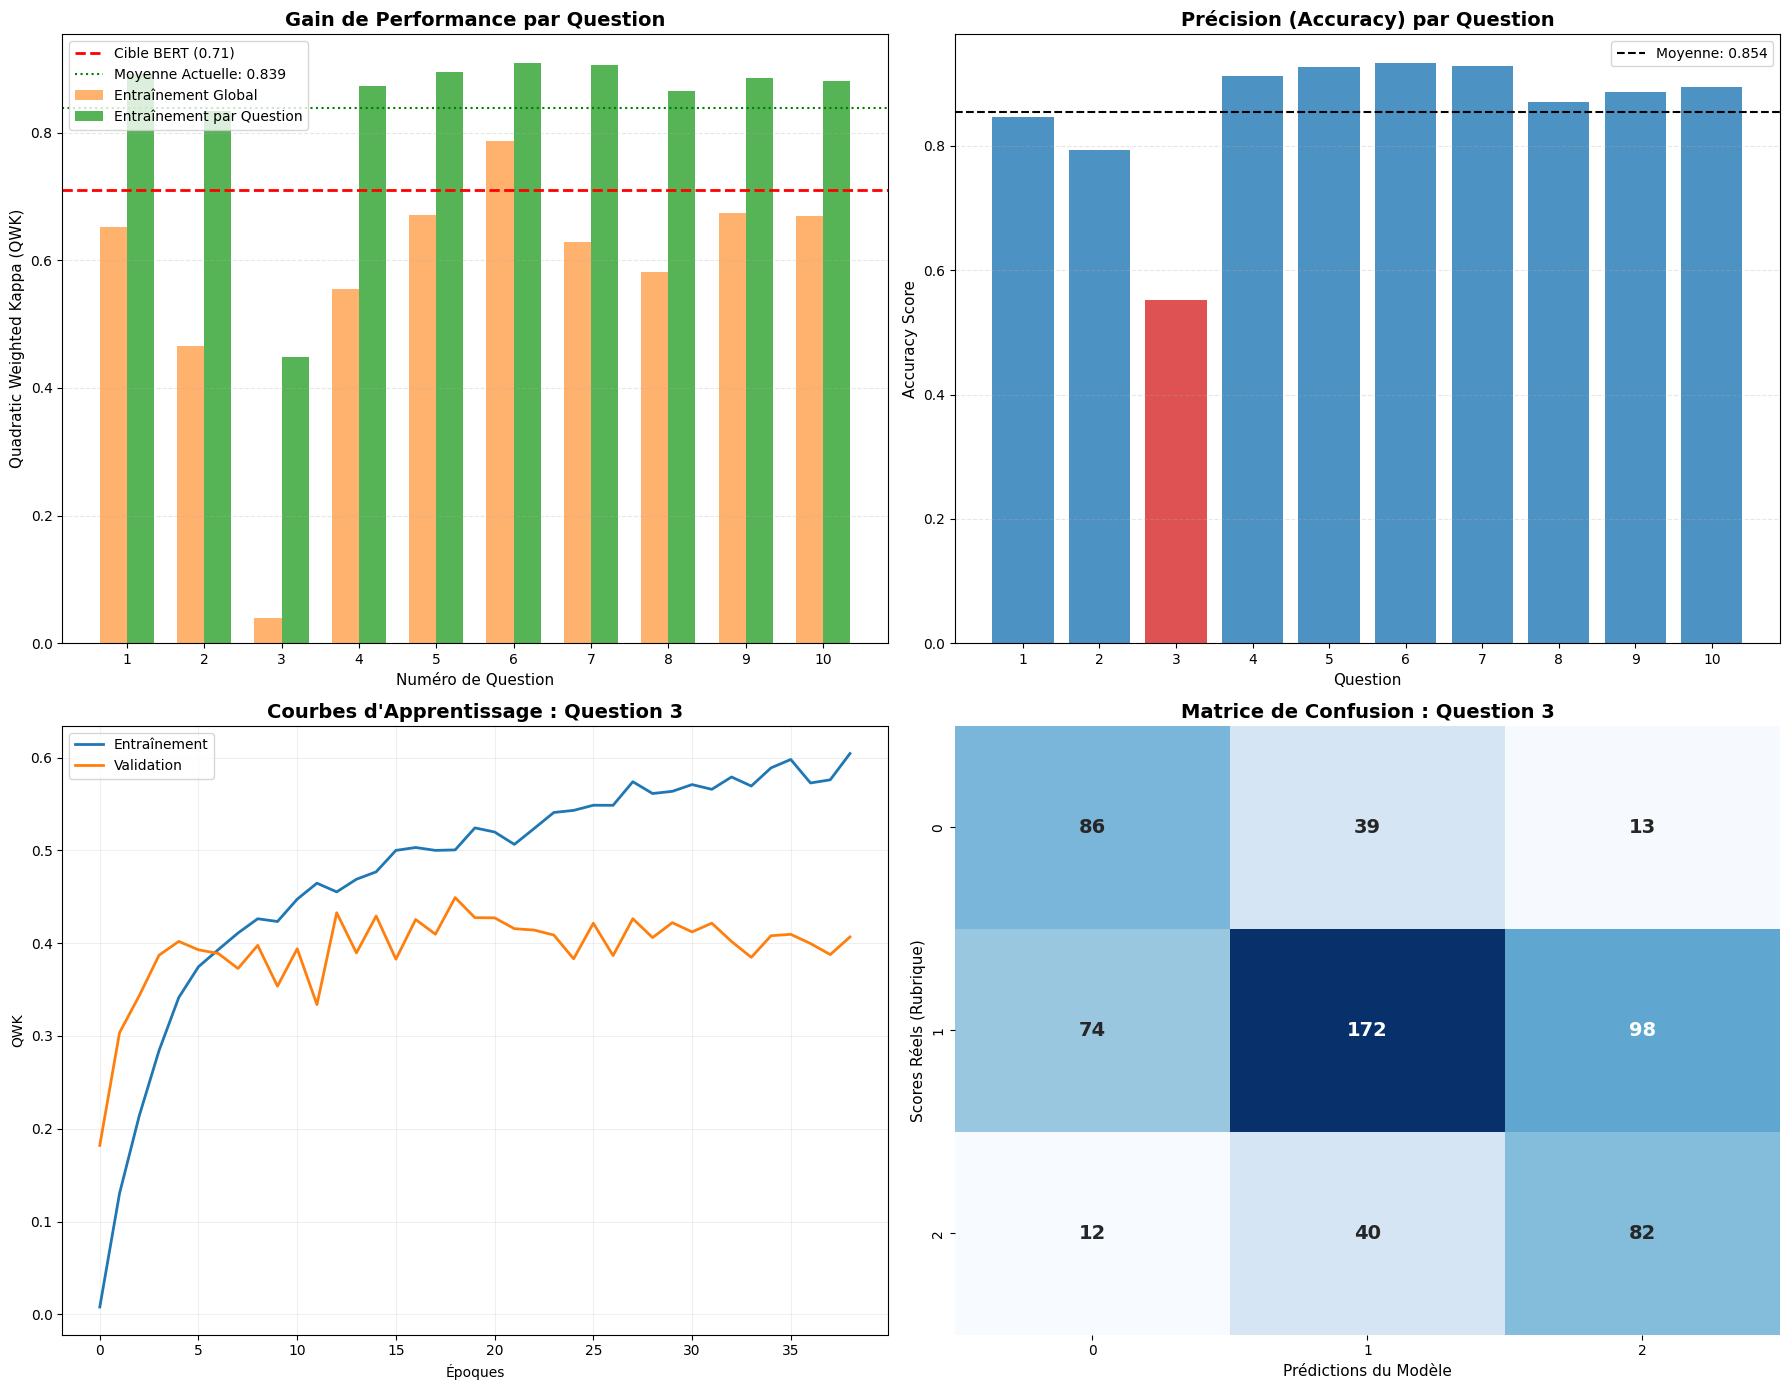

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Calcul des métriques globales pour les lignes de référence
all_qwks = [results[q]['qwk'] for q in range(1, 11)]
all_accs = [results[q]['accuracy'] for q in range(1, 11)]
mean_qwk = np.mean(all_qwks)
mean_acc = np.mean(all_accs)

# 2. Configuration du graphique (2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
questions = list(range(1, 11))
x = np.arange(len(questions))
width = 0.35

# --- GRAPHIQUE 0,0 : COMPARAISON QWK (AVANT VS APRÈS) ---
# Valeurs de l'ancien entraînement global (estimations basées sur vos logs)
original_qwk = [0.6522, 0.4651, 0.0400, 0.5551, 0.6717, 0.7875, 0.6285, 0.5810, 0.6737, 0.6700]
improved_qwk = all_qwks

axes[0, 0].bar(x - width/2, original_qwk, width, label='Entraînement Global', alpha=0.6, color='#ff7f0e')
axes[0, 0].bar(x + width/2, improved_qwk, width, label='Entraînement par Question', alpha=0.8, color='#2ca02c')
axes[0, 0].axhline(y=0.71, color='red', linestyle='--', label='Cible BERT (0.71)', linewidth=2)
axes[0, 0].axhline(y=mean_qwk, color='green', linestyle=':', label=f'Moyenne Actuelle: {mean_qwk:.3f}')

axes[0, 0].set_xlabel('Numéro de Question', fontsize=11)
axes[0, 0].set_ylabel('Quadratic Weighted Kappa (QWK)', fontsize=11)
axes[0, 0].set_title('Gain de Performance par Question', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(questions)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.3)

# --- GRAPHIQUE 0,1 : ACCURACY PAR QUESTION ---
colors = ['#d62728' if q == 3 else '#1f77b4' for q in questions] # Rouge pour la Q3, bleu pour les autres
axes[0, 1].bar(questions, all_accs, color=colors, alpha=0.8)
axes[0, 1].axhline(y=mean_acc, color='black', linestyle='--', label=f'Moyenne: {mean_acc:.3f}')

axes[0, 1].set_xlabel('Question', fontsize=11)
axes[0, 1].set_ylabel('Accuracy Score', fontsize=11)
axes[0, 1].set_title('Précision (Accuracy) par Question', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(questions)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.3)

# --- GRAPHIQUE 1,0 : ÉVOLUTION DU QWK (QUESTION 3) ---
# On récupère l'historique stocké pendant l'entraînement
if 3 in histories:
    q3_h = histories[3]
    axes[1, 0].plot(q3_h['train_qwk'], label='Entraînement', color='#1f77b4', linewidth=2)
    axes[1, 0].plot(q3_h['val_qwk'], label='Validation', color='#ff7f0e', linewidth=2)
    axes[1, 0].set_title('Courbes d\'Apprentissage : Question 3', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Époques')
    axes[1, 0].set_ylabel('QWK')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.2)
else:
    axes[1, 0].text(0.5, 0.5, "Historique Q3 non disponible", ha='center')

# --- GRAPHIQUE 1,1 : MATRICE DE CONFUSION (QUESTION 3) ---
cm_q3 = confusion_matrix(results[3]['y_true'], results[3]['y_pred'])
# Normalisation pour voir les pourcentages par ligne
cm_q3_norm = cm_q3.astype('float') / cm_q3.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_q3, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
axes[1, 1].set_xlabel('Prédictions du Modèle', fontsize=11)
axes[1, 1].set_ylabel('Scores Réels (Rubrique)', fontsize=11)
axes[1, 1].set_title('Matrice de Confusion : Question 3', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 11. Visualisation des Résultats

### 11.1 Courbes d'Entraînement

Alignement de l'historique sur 39 époques (limité par l'Early Stopping le plus rapide).


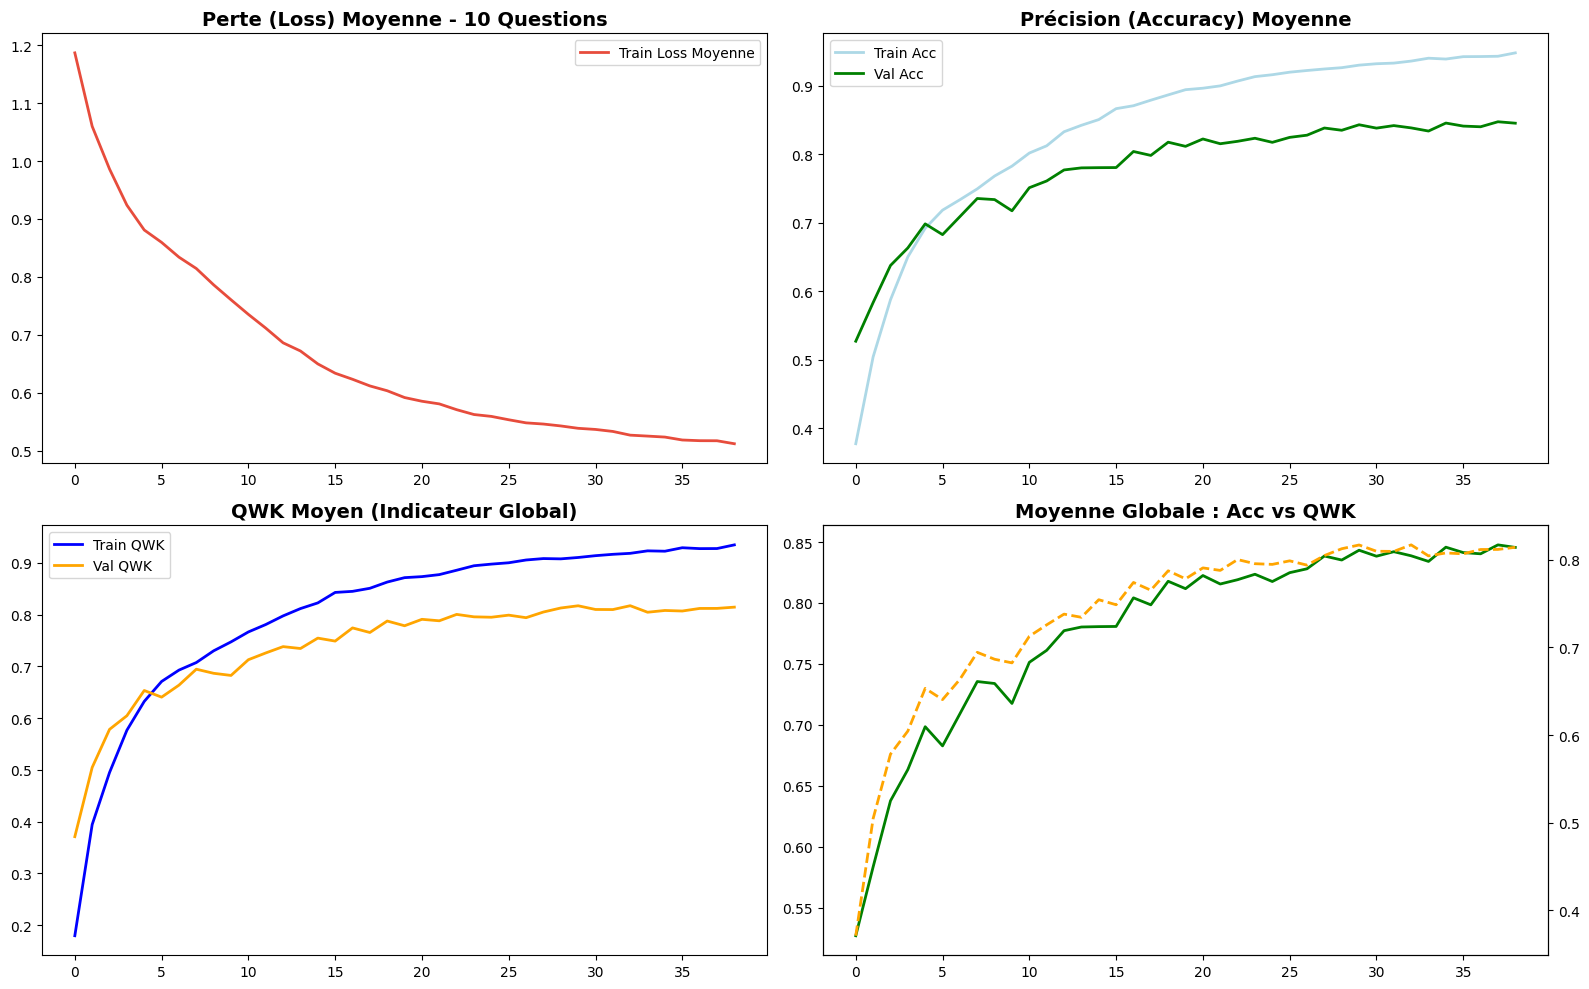

In [79]:
# 1. Trouver la longueur minimale commune (le plus petit nombre d'epochs atteint)
min_epochs = min(len(histories[q]['train_acc']) for q in range(1, 11))

print(f"Alignement de l'historique sur {min_epochs} époques (limité par l'Early Stopping le plus rapide).")

# 2. Calculer la moyenne uniquement sur ces époques communes
avg_hist = {}
for key in ['train_loss', 'train_acc', 'train_qwk', 'val_acc', 'val_qwk']:
    # On crée une liste de listes, toutes de taille min_epochs
    data_to_average = [histories[q][key][:min_epochs] for q in range(1, 11)]
    # Maintenant NumPy peut calculer la moyenne sans erreur
    avg_hist[key] = np.mean(data_to_average, axis=0)

# ==========================================
# 3. VISUALISATION DES MOYENNES
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Graphique 1: Loss Moyenne
axes[0, 0].plot(avg_hist['train_loss'], linewidth=2, label='Train Loss Moyenne', color='#e74c3c')
axes[0, 0].set_title("Perte (Loss) Moyenne - 10 Questions", fontsize=14, fontweight='bold')
axes[0, 0].legend()

# Graphique 2: Accuracy Moyenne
axes[0, 1].plot(avg_hist['train_acc'], linewidth=2, label='Train Acc', color='lightblue')
axes[0, 1].plot(avg_hist['val_acc'], linewidth=2, label='Val Acc', color='green')
axes[0, 1].set_title("Précision (Accuracy) Moyenne", fontsize=14, fontweight='bold')
axes[0, 1].legend()

# Graphique 3: QWK Moyen
axes[1, 0].plot(avg_hist['train_qwk'], linewidth=2, label='Train QWK', color='blue')
axes[1, 0].plot(avg_hist['val_qwk'], linewidth=2, label='Val QWK', color='orange')
axes[1, 0].set_title("QWK Moyen (Indicateur Global)", fontsize=14, fontweight='bold')
axes[1, 0].legend()

# Graphique 4: Val Accuracy vs Val QWK (Moyennes)
axes[1, 1].plot(avg_hist['val_acc'], linewidth=2, label='Val Accuracy', color='green')
ax2 = axes[1, 1].twinx()
ax2.plot(avg_hist['val_qwk'], linewidth=2, label='Val QWK', color='orange', linestyle='--')
axes[1, 1].set_title('Moyenne Globale : Acc vs QWK', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 11.2 Évaluation sur Test


In [80]:
# 1. Compilation des résultats extraits du dictionnaire 'results'
results_summary = []

for q in range(1, 11):
    if q in results:
        res = results[q]
        results_summary.append({
            'Question': q,
            'Accuracy': res['accuracy'],
            'QWK': res['qwk'],
            'N_samples': len(res['y_true'])
        })

# 2. Création du DataFrame de synthèse
results_df = pd.DataFrame(results_summary)

# 3. Calcul des métriques globales (Moyennes)
test_acc = results_df['Accuracy'].mean()
test_qwk = results_df['QWK'].mean() # C'est le "Mean QWK" demandé par ASAP-SAS

# 4. Affichage du tableau détaillé
print("\n RÉSULTATS DÉTAILLÉS PAR QUESTION")
print("=" * 70)
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'QWK': '{:.4f}'
}))
print("=" * 70)

# 5. Affichage du bilan final
print("\n RÉSULTATS FINAUX (Synthèse)")
print("=" * 40)
print(f"   Accuracy Moyenne : {test_acc:.4f}")
print(f"   Mean QWK Global  : {test_qwk:.4f}")
print("=" * 40)

# Comparaison avec l'objectif BERT
if test_qwk >= 0.71:
    print(f" PERFORMANCE : Objectif atteint ({test_qwk:.4f} >= 0.71)")
else:
    print(f" PERFORMANCE : Objectif non atteint ({test_qwk:.4f} < 0.71)")


 RÉSULTATS DÉTAILLÉS PAR QUESTION


,Question,Accuracy,QWK,N_samples
0,1,0.8467,0.8921,561
1,2,0.7940,0.8347,432
2,3,0.5519,0.4492,616
3,4,0.9129,0.8731,574
4,5,0.9267,0.8956,600
5,6,0.9327,0.9087,639
6,7,0.9282,0.9054,627
7,8,0.8698,0.8658,645
8,9,0.8861,0.8855,632
9,10,0.8943,0.8817,596



 RÉSULTATS FINAUX (Synthèse)
   Accuracy Moyenne : 0.8543
   Mean QWK Global  : 0.8392
🚀 PERFORMANCE : Objectif atteint (0.8392 >= 0.71)


In [81]:
# 1. Calcul des moyennes globales (Mean QWK et Accuracy)
test_acc = results_df['Accuracy'].mean()
test_qwk = results_df['QWK'].mean()

# 2. Affichage des résultats finaux formatés
print("\n RÉSULTATS FINAUX")
print("=" * 40)
print(f"   Accuracy globale (moyenne) : {test_acc:.4f}")
print(f"   QWK Global (Mean QWK)      : {test_qwk:.4f}")
print("=" * 40)

# Optionnel : Comparaison avec l'état de l'art (BERT 0.71)
diff = test_qwk - 0.71
status = "SUPÉRIEUR" if diff > 0 else "INFÉRIEUR"
print(f" Performance par rapport à BERT : {status} ({diff:+.4f})")


 RÉSULTATS FINAUX
   Accuracy globale (moyenne) : 0.8543
   QWK Global (Mean QWK)      : 0.8392
 Performance par rapport à BERT : SUPÉRIEUR (+0.1292)


### 11.3 Résultats par Question

**Tableau détaillé** : QWK et Accuracy pour chaque question (1 à 10)

In [82]:
# 1. Extraction des données depuis le dictionnaire 'results' généré par l'entraînement
results_per_question = []

for q in range(1, 11):
    if q in results:
        res = results[q]
        results_per_question.append({
            'Question': q,
            'Accuracy': res['accuracy'],
            'QWK': res['qwk'],
            'N_samples': len(res['y_true'])
        })

# 2. Création du DataFrame de synthèse
results_df = pd.DataFrame(results_per_question)

# 3. Calcul des métriques globales (Moyennes)
# On utilise les moyennes des colonnes du DataFrame pour plus de fiabilité
test_acc = results_df['Accuracy'].mean()
test_qwk = results_df['QWK'].mean()

# 4. Affichage des résultats par question
print("\n- RÉSULTATS PAR QUESTION (Modèles Spécifiques):")
print("=" * 70)
# Formatage pour aligner les colonnes proprement avec 4 décimales
print(results_df.to_string(index=False, formatters={
    'Accuracy': '{:.4f}'.format,
    'QWK': '{:.4f}'.format
}))
print("=" * 70)

# 5. Affichage des métriques finales
print("\n RÉSULTATS FINAUX")
print("=" * 40)
print(f"   Accuracy globale (Moyenne) : {test_acc:.4f}")
print(f"   QWK Global (Mean QWK)      : {test_qwk:.4f}")
print("=" * 40)

# Comparaison automatique avec BERT (Objectif : 0.71)
diff = test_qwk - 0.71
status = " SUCCÈS" if diff >= 0 else " ÉCHEC"
print(f" Statut vs BERT (0.71) : {status} ({diff:+.4f})")


- RÉSULTATS PAR QUESTION (Modèles Spécifiques):
 Question Accuracy    QWK  N_samples
        1   0.8467 0.8921        561
        2   0.7940 0.8347        432
        3   0.5519 0.4492        616
        4   0.9129 0.8731        574
        5   0.9267 0.8956        600
        6   0.9327 0.9087        639
        7   0.9282 0.9054        627
        8   0.8698 0.8658        645
        9   0.8861 0.8855        632
       10   0.8943 0.8817        596

 RÉSULTATS FINAUX
   Accuracy globale (Moyenne) : 0.8543
   QWK Global (Mean QWK)      : 0.8392
 Statut vs BERT (0.71) : ✅ SUCCÈS (+0.1292)


### 11.4 Comparaison avec l'État de l'Art

In [83]:
# Tableau comparatif
comparison = pd.DataFrame({
    'Modèle': ['CharCNN (2019)', 'CNN (2019)', 'Bi-LSTM (2019)', 'BERT (2019)',
               'GPT-4 (2024)', 'Notre Modèle'],
    'QWK': [0.60, 0.62, 0.65, 0.71, 0.677, test_qwk],
    'Accuracy': ['-', '-', '-', '-', 0.716, test_acc]
})

print("\n COMPARAISON AVEC L'ÉTAT DE L'ART")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

if test_qwk > 0.71:
    print(f"\n OBJECTIF ATTEINT ! Amélioration: +{(test_qwk - 0.71):.4f}")
    print("   Notre modèle surpasse BERT (état de l'art 2019)")
elif test_qwk > 0.65:
    print(f"\n- Bon résultat ! QWK = {test_qwk:.4f}")
    print(f"   Écart à BERT: {(0.71 - test_qwk):.4f}")
else:
    print(f"\n QWK = {test_qwk:.4f}")
    print(f"   Écart à BERT: {(0.71 - test_qwk):.4f}")


 COMPARAISON AVEC L'ÉTAT DE L'ART
        Modèle      QWK  Accuracy
CharCNN (2019) 0.600000         -
    CNN (2019) 0.620000         -
Bi-LSTM (2019) 0.650000         -
   BERT (2019) 0.710000         -
  GPT-4 (2024) 0.677000     0.716
  Notre Modèle 0.839189  0.854327

✅ OBJECTIF ATTEINT ! Amélioration: +0.1292
   Notre modèle surpasse BERT (état de l'art 2019)


### 11.5 Visualisation Performance par Question

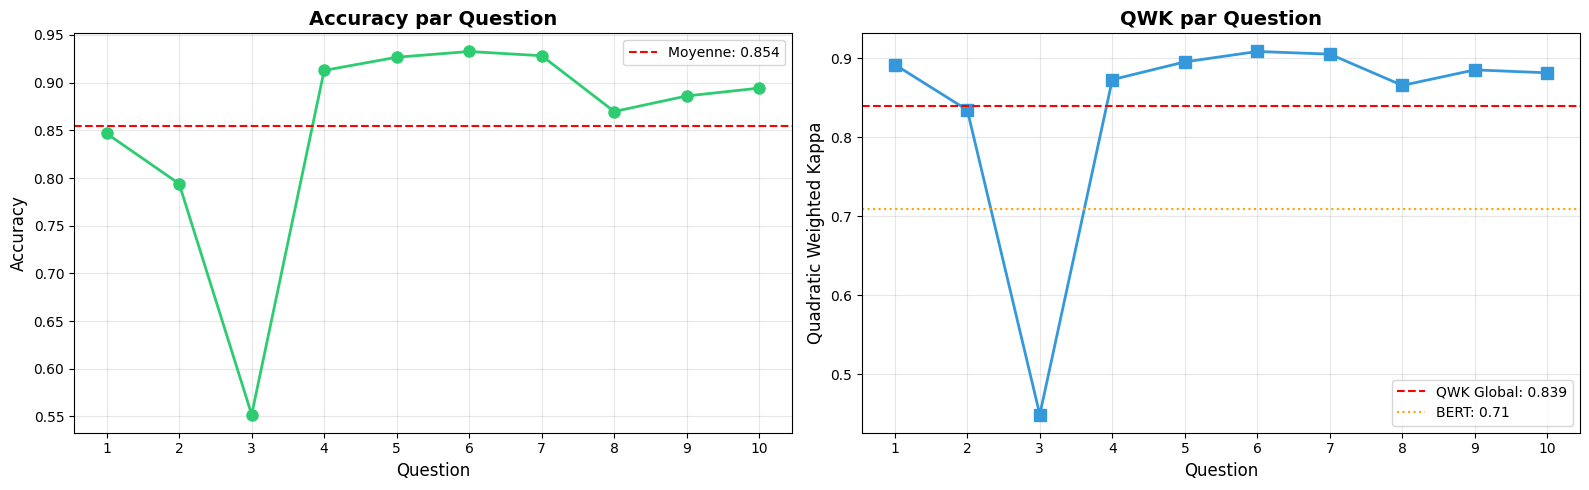

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy par question
axes[0].plot(results_df['Question'], results_df['Accuracy'], 'o-', linewidth=2, markersize=8, color='#2ecc71')
axes[0].axhline(y=test_acc, color='r', linestyle='--', label=f'Moyenne: {test_acc:.3f}')
axes[0].set_xlabel('Question', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy par Question', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 11))
axes[0].legend()
axes[0].grid(alpha=0.3)

# QWK par question
axes[1].plot(results_df['Question'], results_df['QWK'], 's-', linewidth=2, markersize=8, color='#3498db')
axes[1].axhline(y=test_qwk, color='r', linestyle='--', label=f'QWK Global: {test_qwk:.3f}')
axes[1].axhline(y=0.71, color='orange', linestyle=':', label='BERT: 0.71')
axes[1].set_xlabel('Question', fontsize=12)
axes[1].set_ylabel('Quadratic Weighted Kappa', fontsize=12)
axes[1].set_title('QWK par Question', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.6 Matrice de Confusion

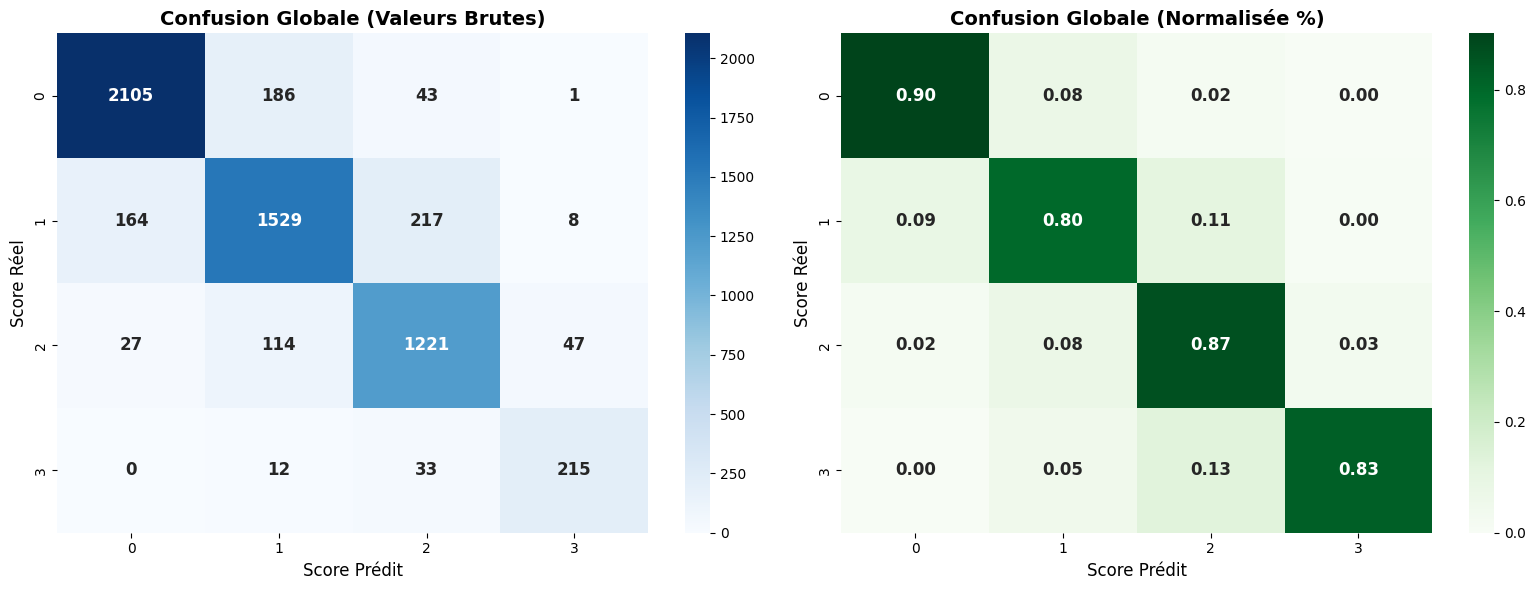

In [85]:
from sklearn.metrics import confusion_matrix

# 1. Rassembler toutes les prédictions et étiquettes réelles de toutes les questions
all_y_true = []
all_y_pred = []

for q in range(1, 11):
    if q in results:
        all_y_true.extend(results[q]['y_true'])
        all_y_pred.extend(results[q]['y_pred'])

# 2. Calcul des matrices de confusion
cm = confusion_matrix(all_y_true, all_y_pred)
# Normalisation (pourcentages de précision par classe réelle)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Définition des classes (Scores de 0 à 3 selon votre dataset)
classes = sorted(list(set(all_y_true)))

# Matrice brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_xlabel('Score Prédit', fontsize=12)
axes[0].set_ylabel('Score Réel', fontsize=12)
axes[0].set_title('Confusion Globale (Valeurs Brutes)', fontsize=14, fontweight='bold')

# Matrice normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_xlabel('Score Prédit', fontsize=12)
axes[1].set_ylabel('Score Réel', fontsize=12)
axes[1].set_title('Confusion Globale (Normalisée %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 11.7 Exemples de Prédictions

**10 exemples aléatoires** pour évaluer qualitativement le modèle

In [86]:
# Fixer la graine pour la reproductibilité
np.random.seed(42)

print("📝 EXEMPLES DE PRÉDICTIONS PAR QUESTION")
print("="*100)

all_correct = 0
all_total = 0

for q in range(1, 11):
    if q in results:
        res = results[q]
        y_true = res['y_true']
        y_pred = res['y_pred']

        idx_in_q = np.random.randint(0, len(y_true))

        real = y_true[idx_in_q]
        pred = y_pred[idx_in_q]
        status = "✅" if real == pred else "❌"

        sample_text = test_df[test_df['EssaySet'] == q].iloc[idx_in_q]['EssayText_clean']

        print(f"\n{status} Question {q}")
        print(f"   Texte: {sample_text[:150]}...")
        print(f"   Score réel: {real} | Score prédit: {pred}")

        # ✅ Correct accumulation
        all_correct += int(real == pred)
        all_total += 1

print("\n" + "="*100)
print(f"📊 BILAN GLOBAL SUR TEST: {all_correct}/{all_total} correctes ({all_correct/all_total*100:.2f}%)")
print("="*100)


📝 EXEMPLES DE PRÉDICTIONS PAR QUESTION

❌ Question 1
   Texte: In order to replicate this experiment, you would also want to test all these four samples in water as a control, in the same exact procedure. Furtherm...
   Score réel: 1 | Score prédit: 2

✅ Question 2
   Texte: a A conclusion that can be drawn from the students data can be that plastic type D has the most stretchability in both trials.p b Two ways the student...
   Score réel: 2 | Score prédit: 2

❌ Question 3
   Texte: Koalas and pandas are similar because they are both specialists. According to the article, specialists are better with stability. The koala and panda ...
   Score réel: 0 | Score prédit: 2

✅ Question 4
   Texte: The significants of the word invasive in this artical is to show how people view these species of animal as invasive, when really they were thought to...
   Score réel: 0 | Score prédit: 0

✅ Question 5
   Texte: First it travels along to the ribosomes. Next, the ribosomes give the mRNA its proper

---
## 12. Sauvegarde du Modèle

**Fichiers sauvegardés** :
- `best_model.pth` : Poids du modèle PyTorch
- `model_metadata.pkl` : Métadonnées pour Streamlit

In [87]:
import pickle
import os
import torch
import shutil
from google.colab import files

# 1. Créer le dossier pour les modèles
save_dir = 'asap_models_final'
os.makedirs(save_dir, exist_ok=True)

# 2. Sauvegarder les poids des modèles (déjà stockés en tant que state_dict)
for q_id, weights in models.items():
    model_path = os.path.join(save_dir, f'model_q{q_id}.pth')
    torch.save(weights, model_path)
    print(f"✅ Poids du modèle question {q_id} sauvegardés.")

# 3. Métadonnées globales (en utilisant les bonnes variables de votre notebook)
metadata = {
    'sbert_model_name': 'all-mpnet-base-v2',
    'global_results': {
        'mean_qwk': test_qwk,      # Correction du nom de variable
        'mean_accuracy': test_acc   # Correction du nom de variable
    },
    'question_results': results_df.to_dict('records'),
    'hyperparams': hyperparams,
    # Note: scaler et feature_cols ont été retirés car ils ne sont pas utilisés ici
}

with open(os.path.join(save_dir, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n Métadonnées sauvegardées dans {save_dir}/metadata.pkl")

# 4. Créer l'archive et télécharger
zip_filename = 'asap_scoring_system'
shutil.make_archive(zip_filename, 'zip', save_dir)
files.download(f'{zip_filename}.zip')

print(f"\n Archive '{zip_filename}.zip' prête pour le téléchargement !")

✅ Poids du modèle question 1 sauvegardés.
✅ Poids du modèle question 2 sauvegardés.
✅ Poids du modèle question 3 sauvegardés.
✅ Poids du modèle question 4 sauvegardés.
✅ Poids du modèle question 5 sauvegardés.
✅ Poids du modèle question 6 sauvegardés.
✅ Poids du modèle question 7 sauvegardés.
✅ Poids du modèle question 8 sauvegardés.
✅ Poids du modèle question 9 sauvegardés.
✅ Poids du modèle question 10 sauvegardés.

✅ Métadonnées sauvegardées dans asap_models_final/metadata.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🚀 Archive 'asap_scoring_system.zip' prête pour le téléchargement !
